# HOP-RAL v2: replay-free analytic class-incremental node classification
Protocol: CGLB class-IL, two classes per task, no inter-task edges, 60/20/20 split per class.
Datasets: **CoraFull** (35 tasks), **Amazon Computers** (5 tasks), **Roman-empire** (9 tasks, heterophilous).
Metrics: AP, BWT, learning accuracy (LA = mean accuracy on each task right after learning it).

Revision 2 of the experiments:
* **5 seeds** (0–4): each seed changes the data split, the network initialization and the random matrices; results are reported as mean ± std.
* **GCN baselines retuned**: 3-layer GCN with 512 hidden units (the backbone of the replay baselines in PUMA), Adam, weight decay 5e-4, learning rate chosen from {0.001, 0.005, 0.01} on seed-0 validation AP, early stopping (patience 50 epochs, at most 500 epochs, best weights restored).
* **Joint training** is trained once on all tasks (upper bound for GCN learners; only its final AP is defined).
* **Roman-empire** is added as a heterophilous dataset (edge homophily 0.05).

The data are downloaded automatically from the public GitHub mirrors (no upload or Drive mount). Everything is printed or plotted inline; nothing is written to result files.
The paper's numbers were produced with this code on CPU (one thread per run). The code is device-agnostic and picks a CUDA GPU (e.g. a Colab T4) when one is available; this version was tested end to end on CPU only, and GPU arithmetic can change the last digit of some results.
`QUICK_RUN = True` runs seed 0 only with the learning rates selected in the paper. The full run (5 seeds, 3 datasets, learning-rate search) took several hours on a 2-core CPU.

In [1]:
import sys, torch
print('Python', sys.version.split()[0], '| PyTorch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0); print('GPU:', p.name, f'| {p.total_memory/1e9:.1f} GB')

Python 3.13.15 | PyTorch 2.11.0+cu130 | CUDA available: True
GPU: Tesla T4 | 15.6 GB


## 1. Code (data loading, baselines, HOP-RAL)

In [2]:
# HOP-RAL v2 experiments: 5 seeds, tuned GCN baselines with early stopping (PUMA backbone),
# heterophilous Roman-empire dataset. Device-agnostic; the paper's numbers were produced on CPU.
import os, time, math, copy, random, json, sys, resource
import numpy as np, scipy.sparse as sp
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CFG = dict(
    datasets=['CoraFull', 'Computers', 'RomanEmpire'],
    seeds=[0, 1, 2, 3, 4],
    # GCN baselines: backbone of the replay baselines in PUMA (3-layer GCN, 512 hidden)
    gcn_hidden=512, dropout=0.5, wd=5e-4, lr_grid=[0.001, 0.005, 0.01],
    max_epochs=500, patience=50, eval_every=5,
    ewc_lambda=1e4, lwf_lambda=1.0, lwf_T=2.0, er_per_class=1,
    # HOP-RAL (fixed before any experiment)
    proj_dim=512, K=2, expand_dim=2048, alpha=0.5, smooth_hops=1,
    gamma_grid=[1e-4, 1e-3, 1e-2, 1e-1, 1.0], K_sweep=[0, 1, 2, 3, 4],
)
URLS = {
    'CoraFull': ['https://raw.githubusercontent.com/shchur/gnn-benchmark/master/data/npz/cora_full.npz',
                 'https://github.com/shchur/gnn-benchmark/raw/master/data/npz/cora_full.npz'],
    'Computers': ['https://raw.githubusercontent.com/shchur/gnn-benchmark/master/data/npz/amazon_electronics_computers.npz',
                  'https://github.com/shchur/gnn-benchmark/raw/master/data/npz/amazon_electronics_computers.npz'],
    'RomanEmpire': ['https://raw.githubusercontent.com/yandex-research/heterophilous-graphs/main/data/roman_empire.npz',
                    'https://github.com/yandex-research/heterophilous-graphs/raw/main/data/roman_empire.npz'],
}
DATA_DIR = 'data'


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)


def download(name):
    import urllib.request
    os.makedirs(DATA_DIR, exist_ok=True)
    fn = {'CoraFull': 'cora_full.npz', 'Computers': 'amazon_electronics_computers.npz',
          'RomanEmpire': 'roman_empire.npz'}[name]
    path = os.path.join(DATA_DIR, fn)
    if os.path.exists(path) and os.path.getsize(path) > 1000:
        return path
    for u in URLS[name]:
        try:
            print('Downloading', u); urllib.request.urlretrieve(u, path)
            with np.load(path, allow_pickle=True) as f: _ = f.files
            return path
        except Exception as e:
            print('  failed:', repr(e))
            if os.path.exists(path): os.remove(path)
    raise RuntimeError('All mirrors failed for ' + name)


def load_raw(name):
    path = download(name)
    with np.load(path, allow_pickle=True) as f:
        f = {k: f[k] for k in f.files}
    if name == 'RomanEmpire':
        X = f['node_features'].astype(np.float32); y = f['node_labels'].astype(np.int64)
        e = f['edges']; n = X.shape[0]
        A = sp.csr_matrix((np.ones(len(e), dtype=np.float32), (e[:, 0], e[:, 1])), shape=(n, n))
        return A, X, y
    A = sp.csr_matrix((f['adj_data'], f['adj_indices'], f['adj_indptr']), shape=tuple(f['adj_shape']))
    if 'attr_data' in f:
        X = sp.csr_matrix((f['attr_data'], f['attr_indices'], f['attr_indptr']), shape=tuple(f['attr_shape']))
    else:
        X = sp.csr_matrix(f['attr_matrix'])
    y = np.asarray(f['labels']).astype(np.int64).ravel()
    return A, X, y


def gcn_norm(A):
    A = A + sp.eye(A.shape[0], dtype=np.float32, format='csr')
    d = np.asarray(A.sum(1)).ravel(); Dm = sp.diags((1.0 / np.sqrt(d)).astype(np.float32))
    return (Dm @ A @ Dm).tocsr().astype(np.float32)


def to_torch_sparse(M):
    M = sp.coo_matrix(M)
    idx = torch.tensor(np.vstack([M.row, M.col]), dtype=torch.long)
    return torch.sparse_coo_tensor(idx, torch.tensor(M.data, dtype=torch.float32), M.shape).coalesce().to(DEVICE)


def prepare(name):
    A, X, y = load_raw(name)
    A = ((A + A.T) > 0).astype(np.float32).tocsr(); A.setdiag(0); A.eliminate_zeros()
    _, y = np.unique(y, return_inverse=True); y = y.astype(np.int64).ravel()
    C = int(y.max()) + 1
    if C % 2 == 1:
        keep = np.where(y < C - 1)[0]; A = A[keep][:, keep]; X = X[keep]; y = y[keep]; C -= 1
    tid = y // 2
    coo = A.tocoo(); m = tid[coo.row] == tid[coo.col]
    A_bd = sp.csr_matrix((coo.data[m], (coo.row[m], coo.col[m])), shape=A.shape)
    A_bd_n = gcn_norm(A_bd)
    if sp.issparse(X):   # non-negative bag-of-words features: divide each row by its sum
        X = X.astype(np.float32).tocsr(); rs = np.asarray(X.sum(1)).ravel(); rs[rs == 0] = 1.0
        X = (sp.diags((1.0 / rs).astype(np.float32)) @ X).tocsr(); feat = 'row-sum'
    else:                # dense real-valued features (Roman-empire): standardize columns
        X = (X - X.mean(0, keepdims=True)) / (X.std(0, keepdims=True) + 1e-8)
        X = sp.csr_matrix(X.astype(np.float32)); feat = 'standardized'
    D = dict(name=name, N=A.shape[0], C=C, nfeat=X.shape[1], y=y, y_t=torch.as_tensor(y, device=DEVICE),
             Xsp=X, X=to_torch_sparse(X), A_bd_sp=A_bd_n, A_full=to_torch_sparse(A_bd_n), feat=feat,
             n_edges_all=A.nnz // 2, n_edges_intra=A_bd.nnz // 2)
    print(f"{name}: nodes={D['N']}, edges={D['n_edges_all']}, intra-task edges={D['n_edges_intra']}, "
          f"features={D['nfeat']} ({feat}), classes={C}, tasks={C // 2}")
    return D


def build_tasks(y, C, seed):
    rng = np.random.RandomState(seed); tasks = []
    for t in range(C // 2):
        cls = [2 * t, 2 * t + 1]; tr, va, te = [], [], []
        for c in cls:
            idx = np.where(y == c)[0]; rng.shuffle(idx); n = len(idx)
            ntr = max(1, int(round(0.6 * n))); nva = max(1, int(round(0.2 * n))) if n >= 3 else 0
            tr += list(idx[:ntr]); va += list(idx[ntr:ntr + nva]); te += list(idx[ntr + nva:])
        tasks.append(dict(classes=cls, nodes=np.sort(np.where(np.isin(y, cls))[0]),
                          train=np.array(tr, dtype=np.int64), val=np.array(va, dtype=np.int64),
                          test=np.array(te, dtype=np.int64)))
    return tasks


# ------------------------------------------------------------------ GCN baselines
class GCN(nn.Module):
    """3-layer GCN (in -> 512 -> 512 -> C); the first layer takes sparse input."""
    def __init__(self, fin, hid, out, dp):
        super().__init__()
        self.W1 = nn.Parameter(torch.empty(fin, hid)); self.b1 = nn.Parameter(torch.zeros(hid))
        nn.init.xavier_uniform_(self.W1)
        self.l2 = nn.Linear(hid, hid); self.l3 = nn.Linear(hid, out); self.dp = dp

    def embed(self, x, A):
        h = F.relu(torch.sparse.mm(A, torch.sparse.mm(x, self.W1) + self.b1))
        h = F.dropout(h, self.dp, self.training)
        return F.relu(torch.sparse.mm(A, self.l2(h)))

    def forward(self, x, A):
        return torch.sparse.mm(A, self.l3(F.dropout(self.embed(x, A), self.dp, self.training)))


def sub_X(D, S):
    return to_torch_sparse(D['Xsp'][S])


def subgraph_adj(D, S):
    return to_torch_sparse(D['A_bd_sp'][S][:, S])


def sparse_eye(n):
    i = torch.arange(n, device=DEVICE)
    return torch.sparse_coo_tensor(torch.stack([i, i]), torch.ones(n, device=DEVICE), (n, n)).coalesce()


def select_mf(D, task, k):   # ER-GNN mean-of-feature selection
    out = []; ytr = D['y'][task['train']]
    for c in task['classes']:
        idx = task['train'][ytr == c]
        if len(idx) == 0: continue
        Xc = torch.tensor(D['Xsp'][idx].toarray(), device=DEVICE)
        d = ((Xc - Xc.mean(0, keepdim=True)) ** 2).sum(1)
        out += list(idx[torch.argsort(d)[:k].cpu().numpy()])
    return np.array(out, dtype=np.int64)


def acc(logits, y):
    return (logits.argmax(1) == y).float().mean().item() if len(y) else float('nan')


def train_early_stop(model, step_fn, val_fn, lr):
    """Adam with early stopping on validation accuracy; restores the best weights."""
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=CFG['wd'])
    best, best_state, bad, ep_run = -1.0, copy.deepcopy(model.state_dict()), 0, 0
    for ep in range(CFG['max_epochs']):
        model.train(); opt.zero_grad(); loss = step_fn(); loss.backward(); opt.step(); ep_run += 1
        if (ep + 1) % CFG['eval_every'] and ep + 1 < CFG['max_epochs']:
            continue
        model.eval()
        with torch.no_grad(): v = val_fn()
        if v > best: best, best_state, bad = v, copy.deepcopy(model.state_dict()), 0
        else:
            bad += CFG['eval_every']
            if bad >= CFG['patience']: break
    model.load_state_dict(best_state); model.eval()
    return best, ep_run


def run_gcn_method(method, D, tasks, seed, lr):
    """Fine-tuning, EWC, LwF, ER-GNN: sequential training over the task stream."""
    set_seed(seed)
    C, T, y = D['C'], len(tasks), D['y_t']
    model = GCN(D['nfeat'], CFG['gcn_hidden'], C, CFG['dropout']).to(DEVICE)
    M = np.zeros((T, T)); Mv = np.zeros((T, T)); epochs = []
    fisher, anchor, old_model, n_old = {}, {}, None, 0
    buf = np.array([], dtype=np.int64)
    for t, task in enumerate(tasks):
        n_seen = 2 * (t + 1); S = task['nodes']
        A_S = subgraph_adj(D, S); xS = sub_X(D, S)
        loc = np.full(D['N'], -1, dtype=np.int64); loc[S] = np.arange(len(S))
        tr_l = torch.as_tensor(loc[task['train']], device=DEVICE); va_l = torch.as_tensor(loc[task['val']], device=DEVICE)
        y_tr = y[torch.as_tensor(task['train'], device=DEVICE)]; y_va = y[torch.as_tensor(task['val'], device=DEVICE)]
        if method == 'ER-GNN' and len(buf) > 0:
            bt = torch.as_tensor(buf, device=DEVICE); xb, yb, Ib = sub_X(D, buf), y[bt], sparse_eye(len(buf))
        old_logits = None
        if method == 'LwF' and old_model is not None:
            with torch.no_grad(): old_logits = old_model(xS, A_S)[:, :n_old]

        def step_fn():
            out = model(xS, A_S)[:, :n_seen]
            loss = F.cross_entropy(out[tr_l], y_tr)
            if method == 'EWC' and fisher:
                loss = loss + CFG['ewc_lambda'] * sum((fisher[n] * (p - anchor[n]) ** 2).sum()
                                                       for n, p in model.named_parameters())
            if method == 'LwF' and old_logits is not None:
                Tt = CFG['lwf_T']
                loss = loss + CFG['lwf_lambda'] * F.kl_div(F.log_softmax(out[:, :n_old] / Tt, 1),
                                                           F.softmax(old_logits / Tt, 1), reduction='batchmean') * Tt * Tt
            if method == 'ER-GNN' and len(buf) > 0:
                loss = loss + F.cross_entropy(model(xb, Ib)[:, :n_seen], yb)
            return loss

        _, ep = train_early_stop(model, step_fn, lambda: acc(model(xS, A_S)[:, :n_seen][va_l], y_va), lr)
        epochs.append(ep)
        if method == 'EWC':
            model.zero_grad()
            F.cross_entropy(model(xS, A_S)[:, :n_seen][tr_l], y_tr).backward()
            for n, p in model.named_parameters():
                g = p.grad.detach() ** 2 if p.grad is not None else torch.zeros_like(p)
                fisher[n] = fisher[n] + g if n in fisher else g
                anchor[n] = p.detach().clone()
            model.zero_grad()
        if method == 'LwF':
            old_model = copy.deepcopy(model).eval(); n_old = n_seen
        if method == 'ER-GNN':
            buf = np.concatenate([buf, select_mf(D, task, CFG['er_per_class'])])
        with torch.no_grad():
            pred = model(D['X'], D['A_full'])[:, :n_seen].argmax(1)
        for j in range(t + 1):
            for key, Mx in (('test', M), ('val', Mv)):
                idx = torch.as_tensor(tasks[j][key], device=DEVICE)
                Mx[t, j] = (pred[idx] == y[idx]).float().mean().item() if len(idx) else np.nan
    return M, Mv, dict(mean_epochs=float(np.mean(epochs)))


def run_joint(D, tasks, seed, lr):
    """Joint training on all tasks at once (upper bound); only the final-step accuracies are defined."""
    set_seed(seed)
    C, T, y = D['C'], len(tasks), D['y_t']
    model = GCN(D['nfeat'], CFG['gcn_hidden'], C, CFG['dropout']).to(DEVICE)
    tr = torch.as_tensor(np.concatenate([t['train'] for t in tasks]), device=DEVICE)
    va = torch.as_tensor(np.concatenate([t['val'] for t in tasks]), device=DEVICE)
    X, A = D['X'], D['A_full']
    _, ep = train_early_stop(model, lambda: F.cross_entropy(model(X, A)[tr], y[tr]),
                             lambda: acc(model(X, A)[va], y[va]), lr)
    with torch.no_grad(): pred = model(X, A).argmax(1)
    row = np.array([(pred[torch.as_tensor(t['test'], device=DEVICE)] == y[torch.as_tensor(t['test'], device=DEVICE)]).float().mean().item() for t in tasks])
    rowv = np.array([(pred[torch.as_tensor(t['val'], device=DEVICE)] == y[torch.as_tensor(t['val'], device=DEVICE)]).float().mean().item() for t in tasks])
    return row, rowv, dict(epochs=ep)


# ------------------------------------------------------------------ analytic learners
def dense_X(D):
    return torch.tensor(D['Xsp'].toarray(), device=DEVICE) if D['nfeat'] <= 1000 else None


def build_hopral_features(D, seed, K, use_prop=True, hop_concat=True, use_expand=True):
    g = torch.Generator().manual_seed(1000 + seed)
    P = (torch.randn(D['nfeat'], CFG['proj_dim'], generator=g) / math.sqrt(CFG['proj_dim'])).to(DEVICE)
    H = torch.sparse.mm(D['X'], P); hops = [H]
    if use_prop:
        for _ in range(K):
            H = torch.sparse.mm(D['A_full'], H); hops.append(H)
    blocks = hops if (use_prop and hop_concat) else [hops[-1]]
    Zlin = torch.cat([F.normalize(b, dim=1) for b in blocks], 1)
    if not use_expand:
        return Zlin
    We = (torch.randn(Zlin.shape[1], CFG['expand_dim'], generator=g) / math.sqrt(Zlin.shape[1])).to(DEVICE)
    return torch.cat([Zlin, F.normalize(F.relu(Zlin @ We), dim=1)], 1)


def gcn_encoder_features(D, tasks, seed, base_tasks, lr):
    """AL-GNN-style: GCN trained by backpropagation on a base set of tasks, then frozen."""
    set_seed(seed)
    model = GCN(D['nfeat'], CFG['gcn_hidden'], D['C'], CFG['dropout']).to(DEVICE)
    S = np.sort(np.concatenate([tasks[j]['nodes'] for j in range(base_tasks)]))
    tr = np.concatenate([tasks[j]['train'] for j in range(base_tasks)])
    va = np.concatenate([tasks[j]['val'] for j in range(base_tasks)]); n_base = 2 * base_tasks
    loc = np.full(D['N'], -1, dtype=np.int64); loc[S] = np.arange(len(S))
    A_S = subgraph_adj(D, S); xS = sub_X(D, S)
    tr_l, va_l = torch.as_tensor(loc[tr], device=DEVICE), torch.as_tensor(loc[va], device=DEVICE)
    y_tr, y_va = D['y_t'][torch.as_tensor(tr, device=DEVICE)], D['y_t'][torch.as_tensor(va, device=DEVICE)]
    train_early_stop(model, lambda: F.cross_entropy(model(xS, A_S)[:, :n_base][tr_l], y_tr),
                     lambda: acc(model(xS, A_S)[:, :n_base][va_l], y_va), lr)
    with torch.no_grad():
        E = model.embed(D['X'], D['A_full'])
    g = torch.Generator().manual_seed(2000 + seed)
    We = (torch.randn(E.shape[1], CFG['expand_dim'], generator=g) / math.sqrt(E.shape[1])).to(DEVICE)
    return torch.cat([F.normalize(E, dim=1), F.normalize(F.relu(E @ We), dim=1)], 1)


def _stats(Z, y, tr, C, weighted):
    Zt = Z[tr].double(); yt = y[tr]
    w = (1.0 / torch.bincount(yt, minlength=C).double()[yt]) if weighted else torch.ones(len(tr), dtype=torch.float64, device=DEVICE)
    Zw = Zt * w[:, None]
    return Zw.T @ Zt, Zw.T @ F.one_hot(yt, C).double()


def _predict(D, Z, G, Q, n_seen, gamma, alpha):
    Dm = G.shape[0]
    L = torch.linalg.cholesky(G + gamma * torch.diagonal(G).mean() * torch.eye(Dm, dtype=torch.float64, device=DEVICE))
    W = torch.cholesky_solve(Q[:, :n_seen], L).float()
    S = Z @ W
    for _ in range(CFG['smooth_hops'] if alpha > 0 else 0):
        S = (1 - alpha) * S + alpha * torch.sparse.mm(D['A_full'], S)
    return S.argmax(1)


def run_analytic(D, tasks, Z, weighted, alpha):
    """Recursive class-balanced ridge. Pass 1 picks gamma by validation AP after the final task
    (the same rule as the v1 notebook); pass 2 replays the stream with that gamma.
    Only G (Dm x Dm) and Q (Dm x C) are kept between tasks."""
    T, C, y, Dm = len(tasks), D['C'], D['y_t'], Z.shape[1]
    G = torch.zeros(Dm, Dm, dtype=torch.float64, device=DEVICE); Q = torch.zeros(Dm, C, dtype=torch.float64, device=DEVICE)
    for task in tasks:
        g_, q_ = _stats(Z, y, torch.as_tensor(task['train'], device=DEVICE), C, weighted); G += g_; Q += q_
    idx = {(j, s): torch.as_tensor(tasks[j][s], device=DEVICE) for j in range(T) for s in ('val', 'test')}
    tab = []
    for gm in CFG['gamma_grid']:
        pred = _predict(D, Z, G, Q, 2 * T, gm, alpha)
        va = np.nanmean([(pred[idx[(j, 'val')]] == y[idx[(j, 'val')]]).float().mean().item() for j in range(T)]) * 100
        te = np.nanmean([(pred[idx[(j, 'test')]] == y[idx[(j, 'test')]]).float().mean().item() for j in range(T)]) * 100
        tab.append((gm, va, te))
    best = max(tab, key=lambda r: r[1])[0]
    G.zero_(); Q.zero_(); M = np.zeros((T, T)); Mv = np.zeros((T, T))
    for t, task in enumerate(tasks):
        g_, q_ = _stats(Z, y, torch.as_tensor(task['train'], device=DEVICE), C, weighted); G += g_; Q += q_
        pred = _predict(D, Z, G, Q, 2 * (t + 1), best, alpha)
        for j in range(t + 1):
            for s, Mx in (('test', M), ('val', Mv)):
                Mx[t, j] = (pred[idx[(j, s)]] == y[idx[(j, s)]]).float().mean().item() if len(idx[(j, s)]) else np.nan
    return M, Mv, dict(gamma=best, gamma_tab=tab, D=Dm, mem_MB=(Dm * Dm + Dm * C) * 8 / 1e6)


def summarize(M):
    T = M.shape[0]; curve = [np.nanmean(M[k, :k + 1]) * 100 for k in range(T)]
    bwt = np.nanmean([M[T - 1, j] - M[j, j] for j in range(T - 1)]) * 100 if T > 1 else 0.0
    return curve[-1], bwt, float(np.mean(curve)), curve


VARIANTS = {
    'HOP-RAL': dict(K=2, use_prop=True, hop_concat=True, use_expand=True, weighted=True, alpha=0.5),
    'w/o propagation (K=0)': dict(K=0, use_prop=False, hop_concat=True, use_expand=True, weighted=True, alpha=0.5),
    'w/o hop concatenation': dict(K=2, use_prop=True, hop_concat=False, use_expand=True, weighted=True, alpha=0.5),
    'w/o random expansion': dict(K=2, use_prop=True, hop_concat=True, use_expand=False, weighted=True, alpha=0.5),
    'w/o class balancing': dict(K=2, use_prop=True, hop_concat=True, use_expand=True, weighted=False, alpha=0.5),
    'w/o score smoothing': dict(K=2, use_prop=True, hop_concat=True, use_expand=True, weighted=True, alpha=0.0),
}
GCN_METHODS = ['Fine-tuning', 'EWC', 'LwF', 'ER-GNN']


## 2. Configuration

In [3]:
import warnings, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')
QUICK_RUN = False          # True: seed 0 only, no learning-rate search (uses the values selected in the paper)
LR_FROM_PAPER = {'CoraFull': {'Fine-tuning': 0.01, 'Joint': 0.01},
                 'Computers': {'Fine-tuning': 0.01, 'Joint': 0.005},
                 'RomanEmpire': {'Fine-tuning': 0.005, 'Joint': 0.01}}
SEEDS = [0] if QUICK_RUN else CFG['seeds']
print('Device:', DEVICE, '| seeds:', SEEDS, '| datasets:', CFG['datasets'])

Device: cuda | seeds: [0, 1, 2, 3, 4] | datasets: ['CoraFull', 'Computers', 'RomanEmpire']


## 3. Run all experiments
Learning rates are tuned on seed 0 (unless `QUICK_RUN`), then every method runs on every seed.

In [4]:
RESULTS = []          # one dict per (dataset, method, seed)

def record(ds, method, seed, M, Mv, secs, extra=None, final_only=False):
    if final_only:
        r = dict(AP=float(np.nanmean(M) * 100), BWT=np.nan, mAP=np.nan, LA=np.nan, val_AP=float(np.nanmean(Mv) * 100))
    else:
        AP, BWT, mAP, _ = summarize(M)
        r = dict(AP=AP, BWT=BWT, mAP=mAP, LA=float(np.nanmean(np.diag(M)) * 100), val_AP=summarize(Mv)[0])
    r.update(dataset=ds, method=method, seed=seed, time_s=secs, M=M)
    if extra: r.update({k: v for k, v in extra.items() if k != 'gamma_tab'}, gamma_tab=extra.get('gamma_tab'))
    RESULTS.append(r)
    print(f"  [{ds}] {method:28s} seed={seed} AP={r['AP']:6.2f} BWT={r['BWT']:7.2f} time={secs:6.1f}s", flush=True)

T0 = time.time()
for ds in CFG['datasets']:
    D = prepare(ds)
    # --- learning-rate selection on seed 0 (validation AP after the final task)
    if QUICK_RUN:
        LR = LR_FROM_PAPER[ds]
    else:
        LR = {}
        tasks0 = build_tasks(D['y'], D['C'], 0)
        for m in ['Fine-tuning', 'Joint']:
            best = None
            for lr in CFG['lr_grid']:
                if m == 'Joint': M, Mv, _ = run_joint(D, tasks0, 0, lr); v = np.nanmean(Mv) * 100
                else: M, Mv, _ = run_gcn_method(m, D, tasks0, 0, lr); v = summarize(Mv)[0]
                print(f'  tuning {ds} {m} lr={lr}: val AP={v:.2f}')
                if best is None or v > best[0] + 1e-9: best = (v, lr)
            LR[m] = best[1]
    print(ds, 'learning rates:', LR)
    for seed in SEEDS:
        tasks = build_tasks(D['y'], D['C'], seed); N = len(tasks)
        for m in GCN_METHODS:
            t0 = time.time(); M, Mv, info = run_gcn_method(m, D, tasks, seed, LR['Fine-tuning']); record(ds, m, seed, M, Mv, time.time() - t0, info)
        t0 = time.time(); M, Mv, info = run_joint(D, tasks, seed, LR['Joint']); record(ds, 'Joint', seed, M, Mv, time.time() - t0, info, final_only=True)
        for base, m in [(1, 'AL-GNN-style, 1-task base'), (N // 2, 'AL-GNN-style, half base')]:
            t0 = time.time(); Z = gcn_encoder_features(D, tasks, seed, base, LR['Joint'])
            M, Mv, info = run_analytic(D, tasks, Z, weighted=False, alpha=0.0); record(ds, m, seed, M, Mv, time.time() - t0, info); del Z
        runs = list(VARIANTS.items()) + [(f'K={K}', dict(K=K, use_prop=True, hop_concat=True, use_expand=True, weighted=True, alpha=0.5))
                                         for K in CFG['K_sweep'] if K not in (0, 2)]
        for m, v in runs:
            t0 = time.time(); Z = build_hopral_features(D, seed, v['K'], v['use_prop'], v['hop_concat'], v['use_expand'])
            M, Mv, info = run_analytic(D, tasks, Z, weighted=v['weighted'], alpha=v['alpha']); record(ds, m, seed, M, Mv, time.time() - t0, info); del Z
    del D
print(f'Total time: {(time.time() - T0) / 60:.1f} min')
df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('M', 'gamma_tab')} for r in RESULTS])

CoraFull: nodes=19793, edges=63421, intra-task edges=36621, features=8710 (row-sum), classes=70, tasks=35
  tuning CoraFull Fine-tuning lr=0.001: val AP=1.90
  tuning CoraFull Fine-tuning lr=0.005: val AP=2.86
  tuning CoraFull Fine-tuning lr=0.01: val AP=2.86
  tuning CoraFull Joint lr=0.001: val AP=2.12
  tuning CoraFull Joint lr=0.005: val AP=74.30
  tuning CoraFull Joint lr=0.01: val AP=74.50
CoraFull learning rates: {'Fine-tuning': 0.005, 'Joint': 0.01}
  [CoraFull] Fine-tuning                  seed=0 AP=  2.54 BWT= -96.56 time=  29.8s
  [CoraFull] EWC                          seed=0 AP=  2.54 BWT= -96.08 time=  41.2s
  [CoraFull] LwF                          seed=0 AP=  2.22 BWT= -96.02 time=  33.7s
  [CoraFull] ER-GNN                       seed=0 AP=  2.90 BWT= -95.74 time=  37.6s
  [CoraFull] Joint                        seed=0 AP= 73.49 BWT=    nan time=  31.8s
  [CoraFull] AL-GNN-style, 1-task base    seed=0 AP=  9.22 BWT= -12.55 time=   4.5s
  [CoraFull] AL-GNN-style, half b

## 4. Main results (mean ± std over seeds)

In [5]:
MAIN = ['Fine-tuning', 'EWC', 'LwF', 'ER-GNN', 'AL-GNN-style, 1-task base', 'AL-GNN-style, half base', 'HOP-RAL', 'Joint']
f = lambda s: f'{s.mean():.1f} ± {s.std(ddof=1) if len(s) > 1 else 0:.1f}'
main = (df[df.method.isin(MAIN)].groupby(['dataset', 'method'])
        .agg(AP=('AP', f), BWT=('BWT', f), LA=('LA', f), time_s=('time_s', lambda s: f'{s.mean():.1f}'), seeds=('seed', 'count')))
pd.set_option('display.width', 220); display(main)
PUBLISHED = {'CoraFull': {'TWP': (21.2, -67.4), 'CaT': (68.5, -5.7), 'PUMA': (77.9, -4.2), 'Joint': (85.3, -2.7)},
             'Computers': {'TWP': (18.9, -96.8), 'CaT': (90.5, -3.1), 'PUMA': (91.7, -2.6), 'Joint': (96.4, -1.9)}}
print('Published in PUMA (Liu et al., IEEE TKDE 2025, Table 2; other backbones, five runs): (AP, BWT)')
for ds, d in PUBLISHED.items(): print(' ', ds, d)

AP          BWT          LA time_s  seeds
dataset     method                                                                      
Computers   AL-GNN-style, 1-task base  57.6 ± 1.4  -15.3 ± 2.0  69.8 ± 2.6    8.2      5
            AL-GNN-style, half base    79.0 ± 0.6  -11.9 ± 1.3  88.6 ± 0.7   20.1      5
            ER-GNN                     20.2 ± 1.1  -91.7 ± 1.3  93.6 ± 2.1   31.6      5
            EWC                        19.8 ± 0.0  -99.6 ± 0.1  99.4 ± 0.1   34.5      5
            Fine-tuning                19.4 ± 1.0  -98.1 ± 3.2  97.9 ± 3.6   32.7      5
            HOP-RAL                    96.8 ± 0.2   -1.3 ± 0.4  97.9 ± 0.2    2.8      5
            Joint                      93.4 ± 4.5    nan ± nan   nan ± nan   94.8      5
            LwF                        19.3 ± 1.0  -94.4 ± 7.4  94.8 ± 6.7   34.0      5
CoraFull    AL-GNN-style, 1-task base   9.9 ± 1.0  -13.7 ± 1.2  23.2 ± 1.6    4.3      5
            AL-GNN-style, half base    58.4 ± 2.0   -8.6 ± 0.4  66.7 ± 1.9   18.5      5
            ER-GNN                      2.7 ± 0.4  -95.8 ± 0.4  95.8 ± 0.4   38.5      5
            EWC                         2.5 ± 0.3  -96.5 ± 0.4  96.2 ± 0.7   38.2      5
            Fine-tuning                 2.6 ± 0.3  -96.6 ± 0.3  96.4 ± 0.5   30.0      5
            HOP-RAL                    79.3 ± 0.7   -3.2 ± 0.3  82.4 ± 0.4    7.1      5
            Joint                      75.4 ± 1.3    nan ± nan   nan ± nan   40.1      5
            LwF                         2.1 ± 0.2  -96.0 ± 0.4  95.4 ± 0.3   32.7      5
RomanEmpire AL-GNN-style, 1-task base  51.6 ± 1.1   -5.6 ± 0.7  56.6 ± 0.6    7.6      5
            AL-GNN-style, half base    55.9 ± 0.8   -6.0 ± 0.4  61.2 ± 0.8   27.5      5
            ER-GNN                     20.7 ± 1.9  -78.8 ± 2.0  90.8 ± 0.6   40.9      5
            EWC                         9.7 ± 0.0  -91.6 ± 0.5  91.1 ± 0.5   37.4      5
            Fine-tuning                 9.7 ± 0.0  -91.4 ± 0.7  91.0 ± 0.6   35.7      5
            HOP-RAL                    62.2 ± 0.7  -12.1 ± 0.7  73.0 ± 0.4    4.5      5
            Joint                      59.2 ± 0.8    nan ± nan   nan ± nan   45.1      5
            LwF                         9.7 ± 0.0  -91.5 ± 1.0  91.1 ± 0.9   37.8      5

Published in PUMA (Liu et al., IEEE TKDE 2025, Table 2; other backbones, five runs): (AP, BWT)
  CoraFull {'TWP': (21.2, -67.4), 'CaT': (68.5, -5.7), 'PUMA': (77.9, -4.2), 'Joint': (85.3, -2.7)}
  Computers {'TWP': (18.9, -96.8), 'CaT': (90.5, -3.1), 'PUMA': (91.7, -2.6), 'Joint': (96.4, -1.9)}


## 5. Learning curves and accuracy matrices

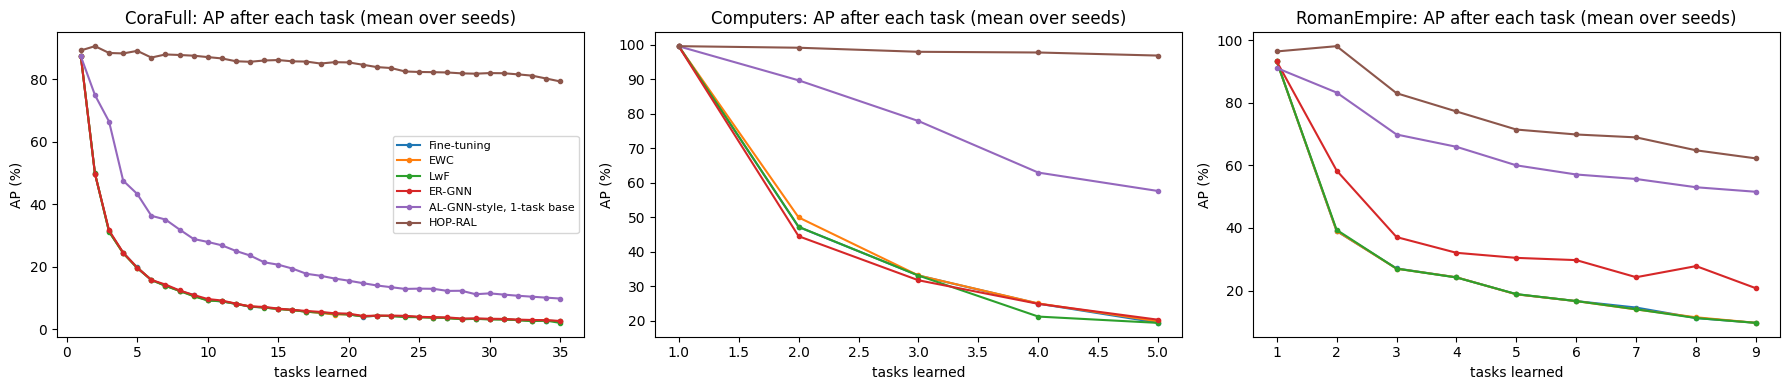

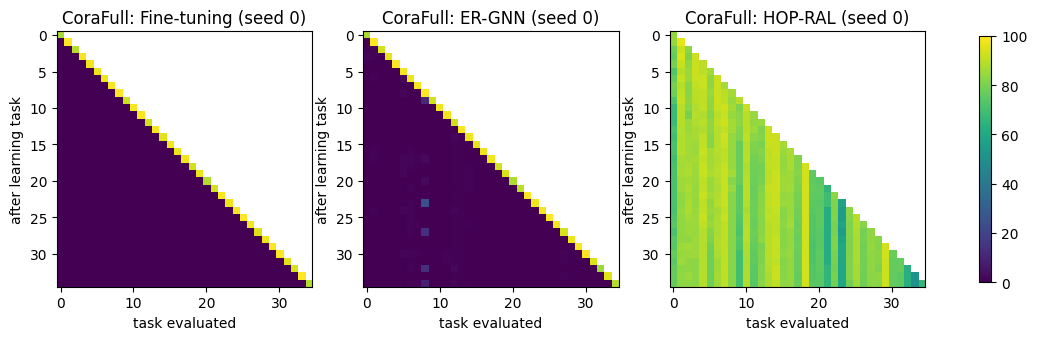

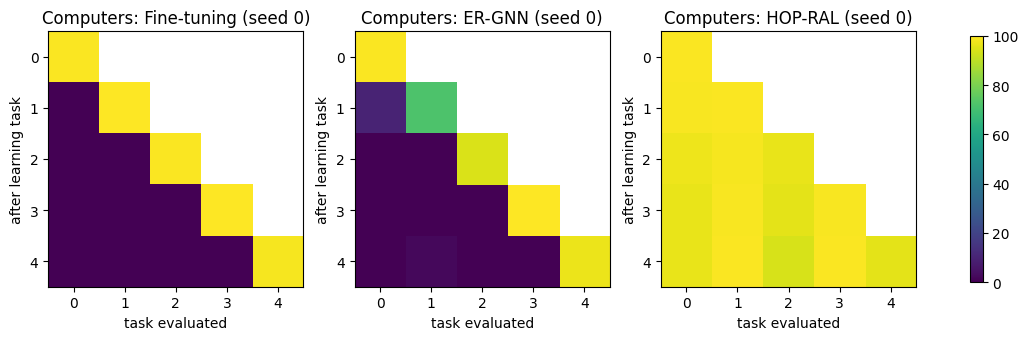

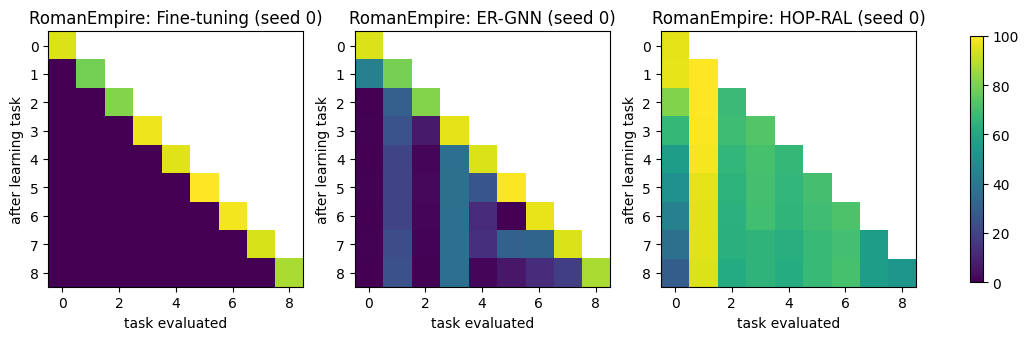

In [6]:
fig, axes = plt.subplots(1, len(CFG['datasets']), figsize=(6 * len(CFG['datasets']), 4))
for ax, ds in zip(np.atleast_1d(axes), CFG['datasets']):
    for m in ['Fine-tuning', 'EWC', 'LwF', 'ER-GNN', 'AL-GNN-style, 1-task base', 'HOP-RAL']:
        curves = np.array([summarize(r['M'])[3] for r in RESULTS if r['dataset'] == ds and r['method'] == m])
        if len(curves): ax.plot(range(1, curves.shape[1] + 1), curves.mean(0), marker='.', label=m)
    ax.set_title(f'{ds}: AP after each task (mean over seeds)'); ax.set_xlabel('tasks learned'); ax.set_ylabel('AP (%)')
np.atleast_1d(axes)[0].legend(fontsize=8); plt.tight_layout(); plt.show()

for ds in CFG['datasets']:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, m in zip(axes, ['Fine-tuning', 'ER-GNN', 'HOP-RAL']):
        r = [r for r in RESULTS if r['dataset'] == ds and r['method'] == m][0]
        M = r['M'].copy() * 100; M[np.triu_indices_from(M, 1)] = np.nan
        im = ax.imshow(M, vmin=0, vmax=100, cmap='viridis'); ax.set_title(f'{ds}: {m} (seed {r["seed"]})')
        ax.set_xlabel('task evaluated'); ax.set_ylabel('after learning task')
    fig.colorbar(im, ax=axes, shrink=0.8); plt.show()

## 6. Ablation, propagation depth and ridge strength

AP          BWT      val_AP       D      mem_MB
dataset     method                                                                        
Computers   HOP-RAL                96.8 ± 0.2   -1.3 ± 0.4  96.8 ± 0.6  3584.0  103.047168
            w/o class balancing    96.8 ± 0.1   -1.3 ± 0.2  97.0 ± 0.7  3584.0  103.047168
            w/o hop concatenation  97.1 ± 0.1   -1.0 ± 0.2  97.0 ± 0.5  2560.0   52.633600
            w/o propagation (K=0)  88.5 ± 0.7   -4.0 ± 0.7  88.3 ± 0.9  2560.0   52.633600
            w/o random expansion   96.5 ± 0.1   -1.2 ± 0.3  96.5 ± 0.6  1536.0   18.997248
            w/o score smoothing    96.6 ± 0.3   -1.5 ± 0.3  96.5 ± 0.6  3584.0  103.047168
CoraFull    HOP-RAL                79.3 ± 0.7   -3.2 ± 0.3  80.5 ± 0.5  3584.0  104.767488
            w/o class balancing    77.8 ± 0.8   -2.2 ± 1.0  78.6 ± 0.4  3584.0  104.767488
            w/o hop concatenation  80.3 ± 0.5   -2.5 ± 0.6  81.1 ± 0.7  2560.0   53.862400
            w/o propagation (K=0)  63.5 ± 1.5   -9.3 ± 0.8  64.4 ± 0.8  2560.0   53.862400
            w/o random expansion   76.9 ± 0.9   -3.8 ± 0.8  77.6 ± 0.3  1536.0   19.734528
            w/o score smoothing    76.8 ± 0.8   -3.3 ± 0.7  78.1 ± 0.5  3584.0  104.767488
RomanEmpire HOP-RAL                62.2 ± 0.7  -12.1 ± 0.7  61.4 ± 0.8  3584.0  103.276544
            w/o class balancing    60.9 ± 1.2   -5.9 ± 0.8  60.2 ± 1.0  3584.0  103.276544
            w/o hop concatenation  58.2 ± 0.8  -11.9 ± 0.9  57.4 ± 0.7  2560.0   52.797440
            w/o propagation (K=0)  59.6 ± 0.6  -13.6 ± 0.7  58.7 ± 0.7  2560.0   52.797440
            w/o random expansion   58.4 ± 1.0  -15.8 ± 1.0  58.0 ± 0.8  1536.0   19.095552
            w/o score smoothing    61.7 ± 0.7  -12.9 ± 1.0  60.9 ± 1.0  3584.0  103.276544

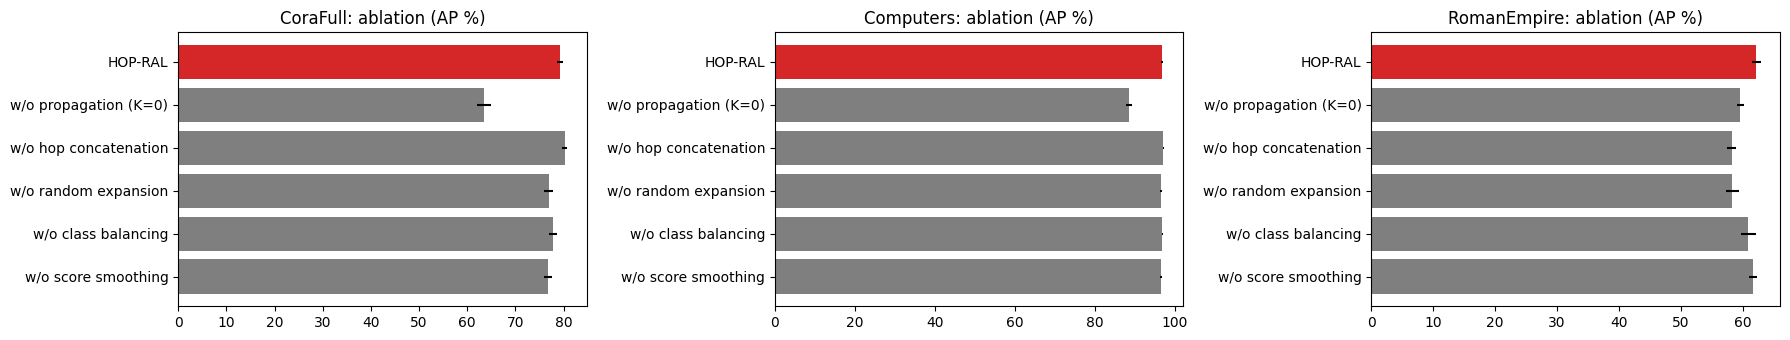

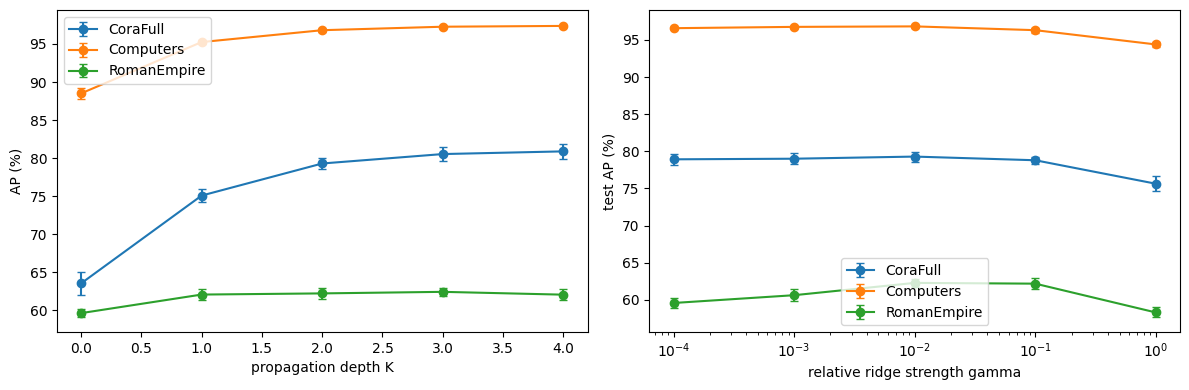

CoraFull gamma, val AP, test AP (mean): [(np.float64(0.0001), np.float64(80.16), np.float64(78.92)), (np.float64(0.001), np.float64(80.33), np.float64(79.0)), (np.float64(0.01), np.float64(80.48), np.float64(79.29)), (np.float64(0.1), np.float64(79.64), np.float64(78.8)), (np.float64(1.0), np.float64(76.41), np.float64(75.64))] | chosen per seed: [0.01, 0.01, 0.01, 0.01, 0.01]
Computers gamma, val AP, test AP (mean): [(np.float64(0.0001), np.float64(96.51), np.float64(96.57)), (np.float64(0.001), np.float64(96.71), np.float64(96.75)), (np.float64(0.01), np.float64(96.74), np.float64(96.81)), (np.float64(0.1), np.float64(96.19), np.float64(96.3)), (np.float64(1.0), np.float64(94.41), np.float64(94.38))] | chosen per seed: [0.01, 0.001, 0.001, 0.001, 0.01]
RomanEmpire gamma, val AP, test AP (mean): [(np.float64(0.0001), np.float64(58.99), np.float64(59.59)), (np.float64(0.001), np.float64(59.88), np.float64(60.64)), (np.float64(0.01), np.float64(61.35), np.float64(62.29)), (np.float64(0.

In [7]:
ABL = list(VARIANTS.keys())
abl = (df[df.method.isin(ABL)].groupby(['dataset', 'method']).agg(AP=('AP', f), BWT=('BWT', f), val_AP=('val_AP', f), D=('D', 'first'), mem_MB=('mem_MB', 'first')))
display(abl)
fig, axes = plt.subplots(1, len(CFG['datasets']), figsize=(6 * len(CFG['datasets']), 3.5))
for ax, ds in zip(np.atleast_1d(axes), CFG['datasets']):
    g = df[(df.dataset == ds) & df.method.isin(ABL)].groupby('method').AP.agg(['mean', 'std']).reindex(ABL)
    ax.barh(g.index, g['mean'], xerr=g['std'].fillna(0), color=['tab:red'] + ['tab:gray'] * (len(g) - 1)); ax.invert_yaxis()
    ax.set_title(f'{ds}: ablation (AP %)')
plt.tight_layout(); plt.show()

kmap = {0: 'w/o propagation (K=0)', 1: 'K=1', 2: 'HOP-RAL', 3: 'K=3', 4: 'K=4'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ds in CFG['datasets']:
    ks = [df[(df.dataset == ds) & (df.method == kmap[k])].AP for k in CFG['K_sweep']]
    axes[0].errorbar(CFG['K_sweep'], [s.mean() for s in ks], yerr=[s.std(ddof=1) if len(s) > 1 else 0 for s in ks], marker='o', capsize=3, label=ds)
    tabs = np.array([r['gamma_tab'] for r in RESULTS if r['dataset'] == ds and r['method'] == 'HOP-RAL'])
    axes[1].errorbar(CFG['gamma_grid'], tabs[:, :, 2].mean(0), yerr=tabs[:, :, 2].std(0, ddof=1) if len(tabs) > 1 else 0, marker='o', capsize=3, label=ds)
axes[0].set_xlabel('propagation depth K'); axes[0].set_ylabel('AP (%)'); axes[0].legend()
axes[1].set_xscale('log'); axes[1].set_xlabel('relative ridge strength gamma'); axes[1].set_ylabel('test AP (%)'); axes[1].legend()
plt.tight_layout(); plt.show()
for ds in CFG['datasets']:
    tabs = np.array([r['gamma_tab'] for r in RESULTS if r['dataset'] == ds and r['method'] == 'HOP-RAL'])
    print(ds, 'gamma, val AP, test AP (mean):', [(g, round(v, 2), round(t, 2)) for g, v, t in tabs.mean(0)],
          '| chosen per seed:', [r['gamma'] for r in RESULTS if r['dataset'] == ds and r['method'] == 'HOP-RAL'])